In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd
import time

apps = {
    'Facebook': 'com.facebook.katana',
    'Instagram': 'com.instagram.android',
    'TikTok': 'com.zhiliaoapp.musically',
    'X_Twitter': 'com.twitter.android',
    'YouTube': 'com.google.android.youtube'
}

def scrape_reviews_stable(app_name, app_id, jumlah=200):
    print(f"Scraping {app_name}...")
    ulasan, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=jumlah
    )
    time.sleep(1)
    df = pd.DataFrame(ulasan)[['userName', 'content', 'score', 'at']]
    df.columns = ['Nama Pengguna', 'Ulasan', 'Rating', 'Tanggal']
    return df

for app, package in apps.items():
    df = scrape_reviews_stable(app, package)
    df.to_excel(f"dataset_final_{app}.xlsx", index=False)
    print(f"{app} → selesai")

Scraping Facebook...
Facebook → selesai
Scraping Instagram...
Instagram → selesai
Scraping TikTok...
TikTok → selesai
Scraping X_Twitter...
X_Twitter → selesai
Scraping YouTube...
YouTube → selesai


In [ ]:
# PREPROCESSING DATA
import pandas as pd
import numpy as np
import string
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import random
random.seed(42)
np.random.seed(42)

nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

additional_stopwords = {
    "aplikasi", "banget", "sangat", "sekali",
    "aja", "kayak", "nih", "nya", "jadi", "dong",
    "tolong", "bang", "mohon", "please", "yang",
    "buat", "bikin", "karena", "agar", "guna"
}

stop_words = stop_words.union(additional_stopwords)

# Load Data Ulasan
apps = ['Facebook', 'Instagram', 'TikTok', 'X_Twitter', 'YouTube']
data_list = []

for app in apps:
    file_name = f'dataset_final_{app}.xlsx'
    df = pd.read_excel(file_name)
    df = df.sort_values(by='Ulasan').reset_index(drop=True)
    df['Platform'] = app.replace('_', ' ')
    data_list.append(df)

df_all = pd.concat(data_list, ignore_index=True)

# Cleaning Text
def clean_text_safe(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    if len(tokens) == 0:
        tokens = [word for word in text.split() if word.strip() != '']

    return " ".join(tokens)

df_all['Ulasan_Bersih'] = df_all['Ulasan'].apply(clean_text_safe)

# TF-IDF Vector
tfidf = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf.fit_transform(df_all['Ulasan_Bersih']).toarray()

tfidf_df = pd.DataFrame(tfidf_matrix, columns=tfidf.get_feature_names_out())
df_vectorized = pd.concat([df_all[['Platform', 'Rating']], tfidf_df], axis=1)

# Load Data Tambahan
tren = pd.read_excel("/content/drive/MyDrive/TA/tren_konten_media_sosial_2025.xlsx")
jangkauan = pd.read_excel("/content/drive/MyDrive/TA/Jangkauan_Iklan_Sosmed_Indonesia_2025.xlsx")

tren.columns = tren.columns.str.strip()
jangkauan.columns = jangkauan.columns.str.strip()

# Standarisasi Nama Platform
def standardize_platform(name):
    name = str(name).strip().lower()
    if 'facebook' in name:
        return 'Facebook'
    elif 'instagram' in name:
        return 'Instagram'
    elif 'tiktok' in name:
        return 'TikTok'
    elif 'twitter' in name or 'x' in name:
        return 'X Twitter'
    elif 'youtube' in name:
        return 'YouTube'
    else:
        return name.title()

df_vectorized['Platform'] = df_vectorized['Platform'].apply(standardize_platform)
jangkauan['Platform'] = jangkauan['Platform'].apply(standardize_platform)

# Proses Data Tren agar Bisa Digabung
tren['Platform'] = tren['Platform'].str.split(',')
tren = tren.explode('Platform')
tren['Platform'] = tren['Platform'].apply(standardize_platform)

# Gabung Semua Data
df_merge = df_vectorized.groupby('Platform').agg({'Rating': 'mean'}).reset_index()
df_final = df_merge.merge(tren, on='Platform', how='left')
df_final = df_final.merge(jangkauan, on='Platform', how='left')

# Simpan ke Excel dengan 2 sheet: df_final & ulasan bersih
with pd.ExcelWriter('data_gabungan_sosial_media.xlsx') as writer:
    df_final.to_excel(writer, sheet_name='Data_Gabungan', index=False)
    df_all[['Platform', 'Ulasan', 'Ulasan_Bersih']].to_excel(writer, sheet_name='Ulasan_Bersih', index=False)

print("✅ Data akhir berhasil digabung dan disimpan dengan sheet ulasan bersih")

# Fungsi untuk memotong teks agar pendek dalam tabel laporan
def shorten(text, max_len=40):
    text = str(text)
    return text[:max_len] + "..." if len(text) > max_len else text


# Potong panjang teks untuk laporan
def shorten_for_report(text, max_len=40):
    text = str(text)
    return text[:max_len] + "..." if len(text) > max_len else text

df_all['Ulasan_Pendek'] = df_all['Ulasan'].apply(lambda x: shorten_for_report(x, 40))
df_all['Ulasan_Bersih_Pendek'] = df_all['Ulasan_Bersih'].apply(lambda x: shorten_for_report(x, 40))
# Ambil hanya 2 ulasan per platform untuk tabel laporan
sample_preprocessing = (
    df_all.groupby('Platform')
          .head(2)[['Platform', 'Ulasan_Pendek', 'Ulasan_Bersih_Pendek']]
          .reset_index(drop=True)
)

print(" Tabel Preprocessing Laporan :")
print(sample_preprocessing)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ Data akhir berhasil digabung dan disimpan dengan sheet ulasan bersih
 Tabel Preprocessing Laporan :
    Platform                                Ulasan_Pendek  \
0   Facebook  1. Durasi video salah tekan langsung gak...   
1   Facebook                                Alhamdulillah   
2  Instagram                                  5in aja lah   
3  Instagram  Akun saya gak bisa di bukak, seperti ter...   
4     TikTok     Aku mau nya masuk cepat dongg tiktok nya   
5     TikTok                                    Apk sesar   
6  X Twitter  APK bhabhi akun gak kenapa-kenapa di tan...   
7  X Twitter  Akun premium pun bisa dibanned. Uda kiri...   
8    YouTube                                       .okeee   
9    YouTube                            1.!!!??? 335 Mega   

                          Ulasan_Bersih_Pendek  
0  durasi video salah tekan langsung gak di...  
1                                alhamdulillah  
2                                           in  
3  akun gak bukak terkena bane

Distribusi Sentimen untuk Facebook:
Sentimen
Netral     171
Positif     26
Negatif      3
Name: count, dtype: int64 



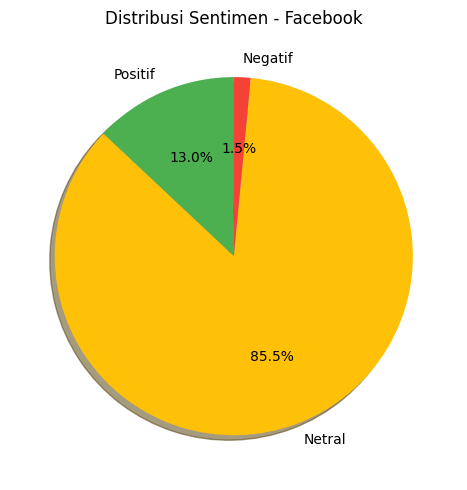

Distribusi Sentimen untuk Instagram:
Sentimen
Netral     168
Positif     30
Negatif      2
Name: count, dtype: int64 



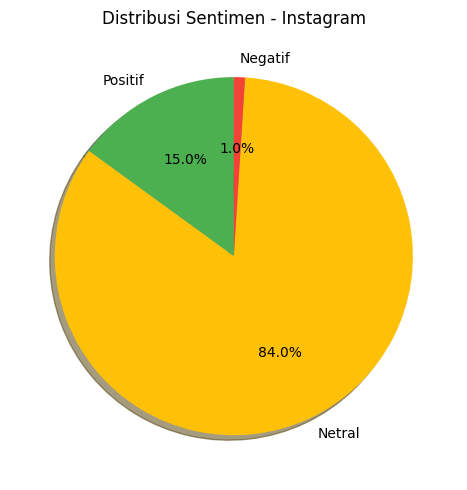

Distribusi Sentimen untuk TikTok:
Sentimen
Netral     157
Positif     42
Negatif      1
Name: count, dtype: int64 



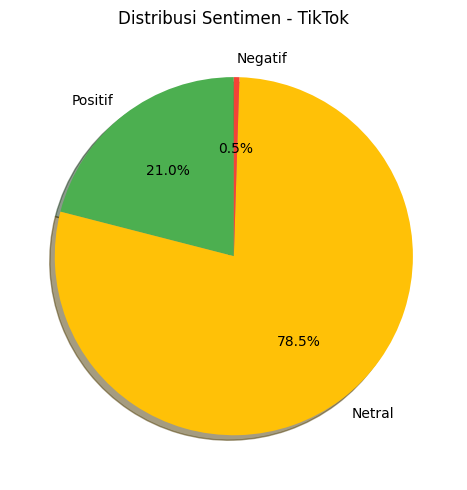

Distribusi Sentimen untuk X Twitter:
Sentimen
Netral     180
Positif     15
Negatif      5
Name: count, dtype: int64 



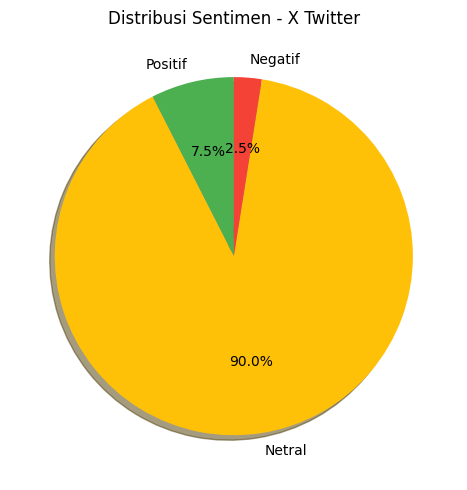

Distribusi Sentimen untuk YouTube:
Sentimen
Netral     177
Positif     20
Negatif      3
Name: count, dtype: int64 



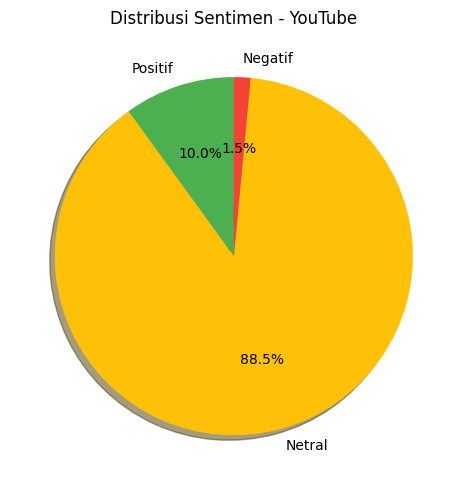

Sentimen   Platform  Negatif  Netral  Positif  Total  Persentase_Positif  \
0          Facebook        3     171       26    200                13.0   
1         Instagram        2     168       30    200                15.0   
2            TikTok        1     157       42    200                21.0   
3         X Twitter        5     180       15    200                 7.5   
4           YouTube        3     177       20    200                10.0   

Sentimen  Persentase_Netral  Persentase_Negatif  
0                      85.5                 1.5  
1                      84.0                 1.0  
2                      78.5                 0.5  
3                      90.0                 2.5  
4                      88.5                 1.5  
✅ Hasil ulasan dengan Sentimen dan ringkasan tersimpan di data_gabungan_sosial_media_sentimen.xlsx


In [ ]:
# FEATURE ENGINEERING
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# Load semua ulasan bersih dari file gabungan
df_all = pd.read_excel('data_gabungan_sosial_media.xlsx', sheet_name='Ulasan_Bersih')
df_all = df_all.sort_values(by=['Platform', 'Ulasan_Bersih']).reset_index(drop=True)

apps = ['Facebook', 'Instagram', 'TikTok', 'X Twitter', 'YouTube']
data_list = []

def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity
    if polarity > 0:
        return 'Positif'
    elif polarity == 0:
        return 'Netral'
    else:
        return 'Negatif'

# Pisahkan per platform & analisis sentimen
for app in apps:
    df = df_all[df_all['Platform'] == app].copy()
    df['Sentimen'] = df['Ulasan_Bersih'].apply(get_sentiment)

    print(f"Distribusi Sentimen untuk {app}:")
    print(df['Sentimen'].value_counts(), "\n")

    # Pie chart
    order = ['Positif', 'Netral', 'Negatif']
    counts = df['Sentimen'].value_counts().reindex(order, fill_value=0)

    plt.figure(figsize=(5, 5))
    counts.plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        shadow=True,
        labels=order,
        colors=['#4CAF50', '#FFC107', '#F44336']
    )
    plt.title(f"Distribusi Sentimen - {app}")
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(f"piechart_sentimen_{app}.png")
    plt.show()

    data_list.append(df)

# Gabungkan semua platform untuk ringkasan
df_ulasan = pd.concat(data_list, ignore_index=True)

# Ringkasan sentimen per platform
df_ulasan = pd.concat(data_list, ignore_index=True)
sentimen_summary = df_ulasan.groupby('Platform')['Sentimen'].value_counts().unstack(fill_value=0)
sentimen_summary['Total'] = sentimen_summary.sum(axis=1)
sentimen_summary['Persentase_Positif'] = (sentimen_summary['Positif'] / sentimen_summary['Total'] * 100).round(2)
sentimen_summary['Persentase_Netral'] = (sentimen_summary['Netral'] / sentimen_summary['Total'] * 100).round(2)
sentimen_summary['Persentase_Negatif'] = (sentimen_summary['Negatif'] / sentimen_summary['Total'] * 100).round(2)
sentimen_summary = sentimen_summary.reset_index()

print(sentimen_summary)

# Simpan File ke Excel
output_file = 'data_gabungan_sosial_media_sentimen.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_ulasan.to_excel(writer, sheet_name='Ulasan_Bersih', index=False)
    sentimen_summary.to_excel(writer, sheet_name='Ringkasan_Sentimen', index=False)

print(f"✅ Hasil ulasan dengan Sentimen dan ringkasan tersimpan di {output_file}")

In [ ]:
# FREKUENSI KATA KUNCI
import pandas as pd
import numpy as np
import re

# Dataset
df_final_ulasan = pd.read_excel('data_gabungan_sosial_media.xlsx', sheet_name='Ulasan_Bersih')
df_final_ulasan = df_final_ulasan.sort_values(by=['Platform', 'Ulasan_Bersih']).reset_index(drop=True)
# Kata kunci utama
keywords = ['iklan', 'konten', 'followers', 'brand', 'engagement',
            'video', 'trending', 'like', 'share']

# Buat dataframe frekuensi kata
freq_df = pd.DataFrame(0, index=df_final_ulasan['Platform'].unique(), columns=keywords)

for platform in df_final_ulasan['Platform'].unique():
    text_data = " ".join(df_final_ulasan[df_final_ulasan['Platform'] == platform]['Ulasan_Bersih']).lower()

    for word in keywords:
        freq_df.loc[platform, word] = len(re.findall(rf'\b{word}\b', text_data))

freq_df = freq_df.reset_index().rename(columns={'index': 'Platform'})
print("Frekuensi Kata Kunci per Platform:")
print(freq_df)

# ENGAGEMENT RATE DARI DATA TREN
# Load data gabungan
df_final = pd.read_excel('data_gabungan_sosial_media.xlsx', sheet_name='Data_Gabungan')

# mapping tren konten → case-insensitive
df_final['Tren Konten'] = df_final['Tren Konten'].str.strip().str.lower()

bobot_tren = {
    'live streaming / siaran langsung': 0.9,
    'video pendek (short-form video)': 0.85,
    'konten autentik & storytelling personal': 0.8,
    'konten dengan ai generatif': 0.75,
    'konten interaktif & komunitas': 0.95,
    'video edutainment / informatif': 0.7,
    'konten seo friendly / mudah ditemukan': 0.65
}

df_final['Bobot_Tren'] = df_final['Tren Konten'].map(bobot_tren)

# Hitung engagement rate skala 0-100
df_final['Engagement_Rate'] = (df_final['Bobot_Tren'] * df_final['Rating']) / 5 * 100

# HITUNG KONVERSI IKLAN
# Konversi = (Engagement Rate * Jangkauan Iklan) / 100
df_final['Konversi (juta)'] = (df_final['Engagement_Rate'] * df_final['Jangkauan Iklan (juta)']) / 100

# Gabung Semua Data
df_result = df_final.merge(freq_df, on='Platform', how='left')

# Simpan hasil akhir
df_result.to_excel('hasil_feature_engineering_sosial_media.xlsx', index=False)
print("✅ Data akhir berhasil disimpan ke hasil_feature_engineering_sosial_media.xlsx")

# Tampilkan ringkasan
print(df_result[['Platform', 'Tren Konten', 'Engagement_Rate', 'Jangkauan Iklan (juta)', 'Konversi (juta)']].head())

Frekuensi Kata Kunci per Platform:
    Platform  iklan  konten  followers  brand  engagement  video  trending  \
0   Facebook      4       2          0      0           0      4         0   
1  Instagram      4       2         10      0           0      8         0   
2     TikTok      2       0          0      0           0      4         0   
3  X Twitter      1       0          0      0           0      0         0   
4    YouTube     28       1          0      0           0      6         0   

   like  share  
0     1      0  
1     4      0  
2     2      0  
3     0      0  
4     0      0  
✅ Data akhir berhasil disimpan ke hasil_feature_engineering_sosial_media.xlsx
    Platform                              Tren Konten  Engagement_Rate  \
0   Facebook         live streaming / siaran langsung           76.410   
1  Instagram          video pendek (short-form video)           63.155   
2  Instagram         live streaming / siaran langsung           66.870   
3  Instagram  konten

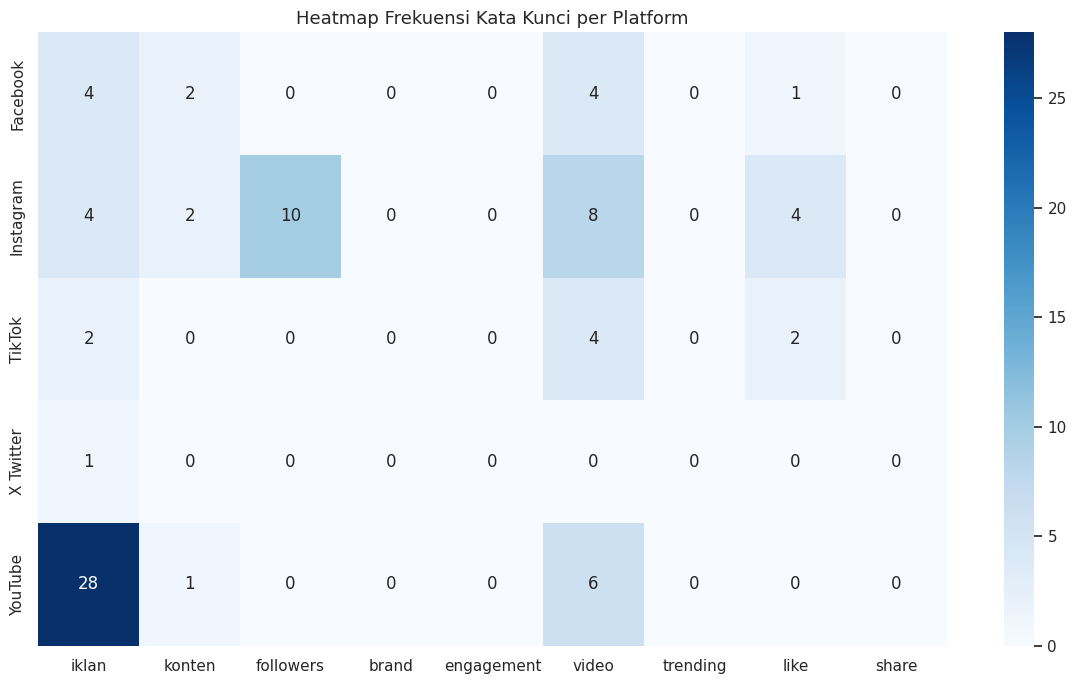

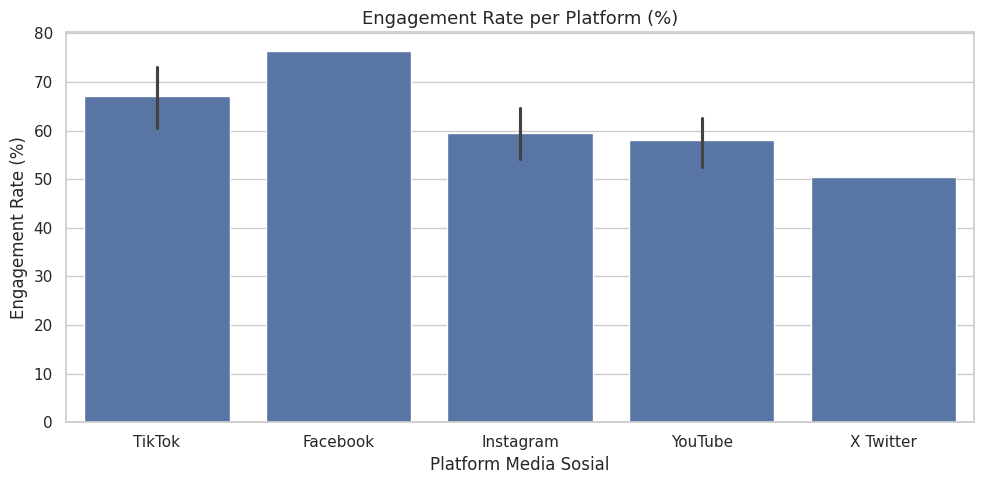

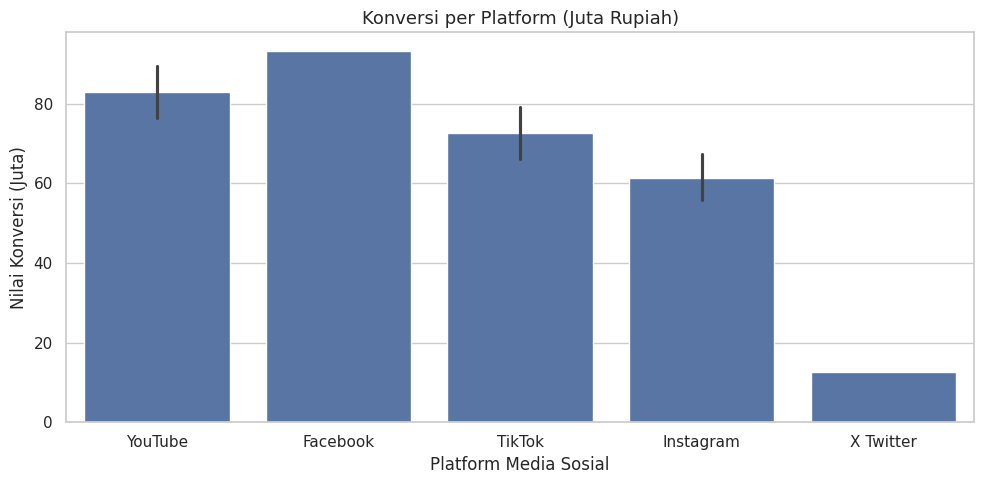

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# HEATMAP FREKUENSI
freq_plot = freq_df.sort_values(by='Platform').set_index('Platform')[keywords]

plt.figure(figsize=(12, 7))
sns.heatmap(freq_plot, annot=True, fmt='d', cmap='Blues')
plt.title("Heatmap Frekuensi Kata Kunci per Platform", fontsize=13)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

plt.savefig("heatmap_frekuensi.png", dpi=600, bbox_inches='tight')
plt.show()

# BARCHART ENGAGEMENT RATE
df_eng = df_result.sort_values(by='Engagement_Rate', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x='Platform',
    y='Engagement_Rate',
    data=df_eng
)
plt.title('Engagement Rate per Platform (%)', fontsize=13)
plt.xlabel('Platform Media Sosial')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('engagement_rate_per_platform.png', dpi=600)
plt.show()

# BARCHART KONVERSI
df_konv = df_result.sort_values(by='Konversi (juta)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x='Platform',
    y='Konversi (juta)',
    data=df_konv
)
plt.title('Konversi per Platform (Juta Rupiah)', fontsize=13)
plt.xlabel('Platform Media Sosial')
plt.ylabel('Nilai Konversi (Juta)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('konversi_per_platform.png', dpi=600)
plt.show()


In [ ]:
# SELEKSI FITUR DENGAN RFE
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Load hasil feature engineering
df = pd.read_excel('hasil_feature_engineering_sosial_media.xlsx')

# Pilih kolom fitur numerik dan target
X = df.drop(columns=['Platform', 'Tren Konten', 'Konversi (juta)'])
y = df['Konversi (juta)']

# Pastikan semua fitur numerik
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Gunakan model dasar Random Forest
base_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Seleksi fitur dengan RFE
rfe = RFE(estimator=base_model, n_features_to_select=10)
rfe.fit(X, y)

# Ambil hasil seleksi
selected_features = X.columns[rfe.support_]

ranking = pd.DataFrame({
    'Fitur': X.columns,
    'Ranking': rfe.ranking_,
    'Dipilih': rfe.support_
}).sort_values(by='Ranking')

print("🔍 Fitur yang Terpilih oleh RFE (Random Forest):")
print(selected_features)

# Simpan hasil seleksi ke file
ranking.to_excel('hasil_seleksi_fitur_RFE_RandomForest.xlsx', index=False)
print("\n✅ Hasil seleksi fitur disimpan ke hasil_seleksi_fitur_RFE_RandomForest.xlsx")

# Dataset baru dengan fitur terpilih
X_selected = X[selected_features]
df_selected = pd.concat([df[['Platform', 'Tren Konten', 'Konversi (juta)']], X_selected], axis=1)
df_selected.to_excel('data_setelah_RFE.xlsx', index=False)

print("\n✅ Dataset baru dengan fitur terpilih disimpan ke data_setelah_RFE.xlsx")

🔍 Fitur yang Terpilih oleh RFE (Random Forest):
Index(['Rating', 'Jangkauan Iklan (juta)', 'Bobot_Tren', 'Engagement_Rate',
       'iklan', 'konten', 'followers', 'video', 'trending', 'like'],
      dtype='object')

✅ Hasil seleksi fitur disimpan ke hasil_seleksi_fitur_RFE_RandomForest.xlsx

✅ Dataset baru dengan fitur terpilih disimpan ke data_setelah_RFE.xlsx


In [ ]:
# PEMBAGIAN DATA SETELAH RFE
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset hasil seleksi fitur RFE
df_rfe = pd.read_excel('data_setelah_RFE.xlsx')

# Cek kolom yang tersedia
print("Kolom yang tersedia setelah RFE:\n", df_rfe.columns.tolist())

# Pisahkan fitur (X) dan target (y)
X = df_rfe.drop(columns=['Platform', 'Tren Konten', 'Konversi (juta)'])
y = df_rfe['Konversi (juta)']

# Pastikan semua kolom numerik
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = y.apply(pd.to_numeric, errors='coerce').fillna(0)

# >>> SIMPAN HASIL SPLIT KE VARIABEL <<<
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Info hasil pembagian
print(" Pembagian Data Berhasil Dilakukan")
print(f"Jumlah data total     : {len(df_rfe)}")
print(f"Jumlah data training   : {X_train.shape[0]}")
print(f"Jumlah data testing    : {X_test.shape[0]}")
print(f"Jumlah fitur terpilih  : {X_train.shape[1]}")

# Simpan hasil split untuk pelatihan model
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.to_excel('data_training_setelah_RFE.xlsx', index=False)
test_data.to_excel('data_testing_setelah_RFE.xlsx', index=False)

print("\n✅ Data training & testing disimpan ke file:")
print("- data_training_setelah_RFE.xlsx")
print("- data_testing_setelah_RFE.xlsx")


Kolom yang tersedia setelah RFE:
 ['Platform', 'Tren Konten', 'Konversi (juta)', 'Rating', 'Jangkauan Iklan (juta)', 'Bobot_Tren', 'Engagement_Rate', 'iklan', 'konten', 'followers', 'video', 'trending', 'like']
 Pembagian Data Berhasil Dilakukan
Jumlah data total     : 21
Jumlah data training   : 16
Jumlah data testing    : 5
Jumlah fitur terpilih  : 10

✅ Data training & testing disimpan ke file:
- data_training_setelah_RFE.xlsx
- data_testing_setelah_RFE.xlsx


In [ ]:
# PELATIHAN MODEL
# Gradient Boosting Regressor

import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load Data Training & Testing
train_data = pd.read_excel('data_training_setelah_RFE.xlsx')
test_data = pd.read_excel('data_testing_setelah_RFE.xlsx')

# Pisahkan fitur dan target
X_train = train_data.drop(columns=['Konversi (juta)'])
y_train = train_data['Konversi (juta)']

X_test = test_data.drop(columns=['Konversi (juta)'])
y_test = test_data['Konversi (juta)']

# Pastikan data numerik
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = y_train.apply(pd.to_numeric, errors='coerce').fillna(0)
y_test = y_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Inisialisasi Model Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,     # jumlah pohon
    learning_rate=0.1,    # kecepatan pembelajaran
    max_depth=3,          # kedalaman pohon
    random_state=42
)


# Latih Model
gb_model.fit(X_train, y_train)

# Prediksi di Data Testing
y_pred = gb_model.predict(X_test)

# Evaluasi Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluasi Model Gradient Boosting:")
print(f"• Mean Absolute Error (MAE): {mae:.4f}")
print(f"• Mean Squared Error (MSE): {mse:.4f}")
print(f"• Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"• R² Score: {r2:.4f}")

# Simpan Hasil Prediksi
df_pred = X_test.copy()
df_pred['Konversi_Actual (juta)'] = y_test.values
df_pred['Konversi_Predicted (juta)'] = y_pred

df_pred.to_excel('prediksi_platform_gradient_boosting.xlsx', index=False)
print("\n✅ Prediksi testing tersimpan di 'prediksi_platform_gradient_boosting.xlsx'")


Evaluasi Model Gradient Boosting:
• Mean Absolute Error (MAE): 16.6359
• Mean Squared Error (MSE): 844.6966
• Root Mean Squared Error (RMSE): 29.0637
• R² Score: -0.0057

✅ Prediksi testing tersimpan di 'prediksi_platform_gradient_boosting.xlsx'


In [ ]:
# XGBRegressor
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Data Training & Testing
train_data = pd.read_excel('data_training_setelah_RFE.xlsx')
test_data = pd.read_excel('data_testing_setelah_RFE.xlsx')

# Pisahkan fitur (X) dan target (y)
X_train = train_data.drop(columns=['Konversi (juta)'])
y_train = train_data['Konversi (juta)']

X_test = test_data.drop(columns=['Konversi (juta)'])
y_test = test_data['Konversi (juta)']

# Pastikan semua data numerik
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = y_train.apply(pd.to_numeric, errors='coerce').fillna(0)
y_test = y_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Inisialisasi Model XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=200,       # jumlah pohon
    learning_rate=0.1,      # kecepatan pembelajaran
    max_depth=4,            # kedalaman pohon
    subsample=0.8,          # proporsi data tiap pohon
    colsample_bytree=0.8,   # proporsi fitur tiap pohon
    random_state=42,
    objective='reg:squarederror',
    eval_metric='rmse'
)

# Latih Model
xgb_model.fit(X_train, y_train)

# Prediksi di Data Testing
y_pred = xgb_model.predict(X_test)

# Evaluasi Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluasi Model XGBoost (Regresi):")
print(f"• Mean Absolute Error (MAE): {mae:.4f}")
print(f"• Mean Squared Error (MSE): {mse:.4f}")
print(f"• Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"• R² Score: {r2:.4f}")

# Simpan Hasil Prediksi
df_pred = X_test.copy()
df_pred['Konversi_Actual (juta)'] = y_test.values
df_pred['Konversi_Predicted (juta)'] = y_pred

df_pred.to_excel('prediksi_platform_xgboost.xlsx', index=False)
print("\n✅ Prediksi testing tersimpan di 'prediksi_platform_xgboost.xlsx'")


Evaluasi Model XGBoost (Regresi):
• Mean Absolute Error (MAE): 14.9743
• Mean Squared Error (MSE): 580.1692
• Root Mean Squared Error (RMSE): 24.0867
• R² Score: 0.3092

✅ Prediksi testing tersimpan di 'prediksi_platform_xgboost.xlsx'


In [ ]:
# CNN
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Data
train_data = pd.read_excel('data_training_setelah_RFE.xlsx')
test_data = pd.read_excel('data_testing_setelah_RFE.xlsx')

X_train = train_data.drop(columns=['Konversi (juta)'])
y_train = train_data['Konversi (juta)']

X_test = test_data.drop(columns=['Konversi (juta)'])
y_test = test_data['Konversi (juta)']

# Bangun Model CNN (Regresi)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')  # output regresi
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Latih Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# Prediksi dan Evaluasi
y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n Evaluasi Model CNN (Regresi):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Simpan Hasil Prediksi
df_pred = X_test.copy()
df_pred['Konversi_Actual (juta)'] = y_test.values
df_pred['Konversi_Predicted (juta)'] = y_pred
df_pred.to_excel('prediksi_platform_cnn.xlsx', index=False)

print("\n✅ Prediksi testing CNN tersimpan di 'prediksi_platform_cnn.xlsx'")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,729 (38.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 4712.2495 - mae: 67.5868 - val_loss: 3895.5952 - val_mae: 61.4415
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - loss: 5212.9990 - mae: 70.6054 - val_loss: 3430.4404 - val_mae: 57.6514
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 4590.4546 - mae: 66.3964 - val_loss: 3000.5459 - val_mae: 53.8654
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 4163.2769 - mae: 62.1942 - val_loss: 2595.2324 - val_mae: 50.0450
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 3347.0332 - mae: 56.9828 - val_loss: 2222.8408 - val_mae: 46.2631
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - loss: 2855.0215 - mae: 52.0260 - val_loss: 1887.4658 - val_mae: 42.5577
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 2217.4412 - mae: 46.1085 - val_loss: 1579.5548 - val_mae: 38.8831
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 2142.4080 - mae: 43.1535 - val_loss: 1292.2344 - val_mae: 35.1340
Epoch 9/50


In [ ]:
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load Data
train_data = pd.read_excel('data_training_setelah_RFE.xlsx')
test_data = pd.read_excel('data_testing_setelah_RFE.xlsx')

# Pisahkan fitur (X) dan target (y)
X_train = train_data.drop(columns=['Konversi (juta)'])
y_train = train_data['Konversi (juta)']

X_test = test_data.drop(columns=['Konversi (juta)'])
y_test = test_data['Konversi (juta)']

# Normalisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inisialisasi Model SVR
svr_model = SVR(
    kernel='rbf',       # opsi lain: 'linear', 'poly', 'sigmoid'
    C=1.0,
    gamma='scale',
    epsilon=0.1
)

# Latih Model
svr_model.fit(X_train_scaled, y_train)

# Prediksi di Data Testing
y_pred = svr_model.predict(X_test_scaled)

# Evaluasi Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluasi Model SVR (Regresi):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Simpan Hasil Prediksi
df_pred = X_test.copy()
df_pred['Konversi_Actual (juta)'] = y_test.values
df_pred['Konversi_Predicted (juta)'] = y_pred

df_pred.to_excel('prediksi_platform_svr.xlsx', index=False)
print("\n✅ Prediksi testing SVR tersimpan di 'prediksi_platform_svr.xlsx'")


Evaluasi Model SVR (Regresi):
MAE  : 20.8907
MSE  : 814.8523
RMSE : 28.5456
R²   : 0.0298

✅ Prediksi testing SVR tersimpan di 'prediksi_platform_svr.xlsx'


In [ ]:
# Evaluasi Model (Regresi)
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load hasil prediksi dari masing-masing model
gb = pd.read_excel('prediksi_platform_gradient_boosting.xlsx')
xgb = pd.read_excel('prediksi_platform_xgboost.xlsx')
svr = pd.read_excel('prediksi_platform_svr.xlsx')
cnn = pd.read_excel('prediksi_platform_cnn.xlsx')

# Pastikan kolom target & prediksi tersedia
models = {
    'Gradient Boosting': gb,
    'XGBoost': xgb,
    'SVR': svr,
    'CNN': cnn
}

# Simpan hasil evaluasi
results = []

for name, df in models.items():
    # Ambil nilai aktual dan prediksi
    y_true = df['Konversi_Actual (juta)']
    y_pred = df['Konversi_Predicted (juta)']

    # Hitung metrik evaluasi
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    })

# Tabel hasil evaluasi
eval_df = pd.DataFrame(results)
print("Hasil Evaluasi Model Regresi:")
print(eval_df)

# Simpan ke file Excel
eval_df.to_excel('evaluasi_model_regresi.xlsx', index=False)
print("\n✅ Hasil evaluasi disimpan ke 'evaluasi_model_regresi.xlsx'")


Hasil Evaluasi Model Regresi:
               Model        MAE         MSE       RMSE        R²
0  Gradient Boosting  16.635864  844.696625  29.063665 -0.005697
1            XGBoost  14.974345  580.169218  24.086702  0.309250
2                SVR  20.890691  814.852274  28.545617  0.029836
3                CNN  13.667414  218.480496  14.781086  0.739877

✅ Hasil evaluasi disimpan ke 'evaluasi_model_regresi.xlsx'


Hasil Evaluasi Semua Model:

               Model        MAE         MSE       RMSE        R²
0  Gradient Boosting  16.635864  844.696625  29.063665 -0.005697
1            XGBoost  14.974345  580.169218  24.086702  0.309250
2                SVR  20.890691  814.852274  28.545617  0.029836
3                CNN  13.667414  218.480496  14.781086  0.739877

 Model Terbaik:
 CNN dengan R² = 0.7398768051272269 dan RMSE = 14.78108574245733


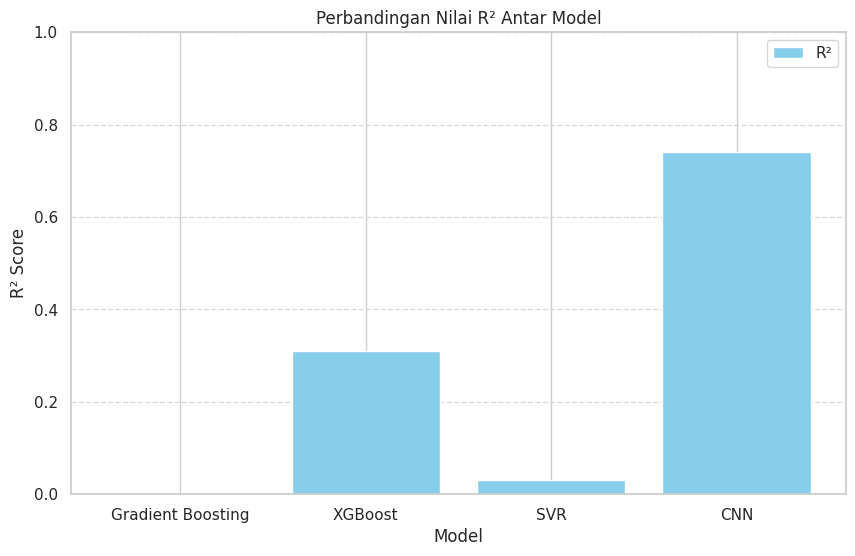

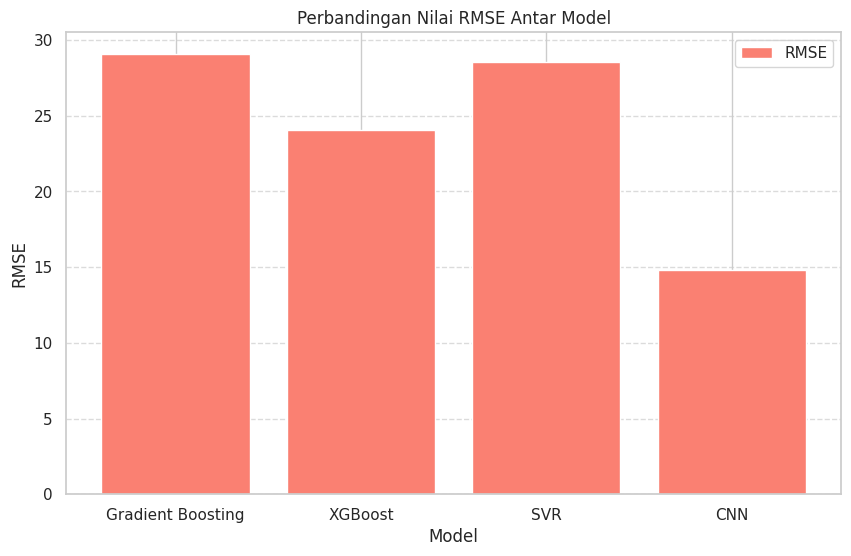


✅ Informasi model terbaik tersimpan di 'model_terbaik.xlsx'


In [ ]:
#  PERBANDINGAN KINERJA MODEL REGRESI
import pandas as pd
import matplotlib.pyplot as plt

# Load hasil evaluasi model dari file sebelumnya
df_eval = pd.read_excel('evaluasi_model_regresi.xlsx')

# Tampilkan tabel evaluasi
print("Hasil Evaluasi Semua Model:\n")
print(df_eval)

# Tentukan model terbaik
#   Berdasarkan kombinasi R² tertinggi & RMSE terendah
best_model = df_eval.sort_values(by=['R²', 'RMSE'], ascending=[False, True]).iloc[0]

print("\n Model Terbaik:")
print(f" {best_model['Model']} dengan R² = {best_model['R²']} dan RMSE = {best_model['RMSE']}")

#  Visualisasi Perbandingan Metrik
plt.figure(figsize=(10,6))
plt.bar(df_eval['Model'], df_eval['R²'], color='skyblue', label='R²')
plt.title('Perbandingan Nilai R² Antar Model')
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.savefig('perbandingan_R2.png', dpi=600)
plt.show()

plt.figure(figsize=(10,6))
plt.bar(df_eval['Model'], df_eval['RMSE'], color='salmon', label='RMSE')
plt.title('Perbandingan Nilai RMSE Antar Model')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.savefig('perbandingan_RMSE.png', dpi=600)
plt.show()

# Simpan model terbaik ke file
best_model.to_frame().T.to_excel('model_terbaik.xlsx', index=False)
print("\n✅ Informasi model terbaik tersimpan di 'model_terbaik.xlsx'")


Jumlah baris prediksi: 5
Jumlah baris testing: 5
Jumlah baris data penuh: 21

 Rata-rata Prediksi Konversi Tiap Platform (CNN):
    Platform  Rata-rata Konversi (juta)
4    YouTube                  75.266899
0   Facebook                  72.799042
2     TikTok                  66.317490
1  Instagram                  60.092041
3  X Twitter                  31.711630

 Platform terbaik: YouTube (75.27 juta)

✅ Hasil tersimpan di 'hasil_interpretasi_platform_cnn.xlsx'


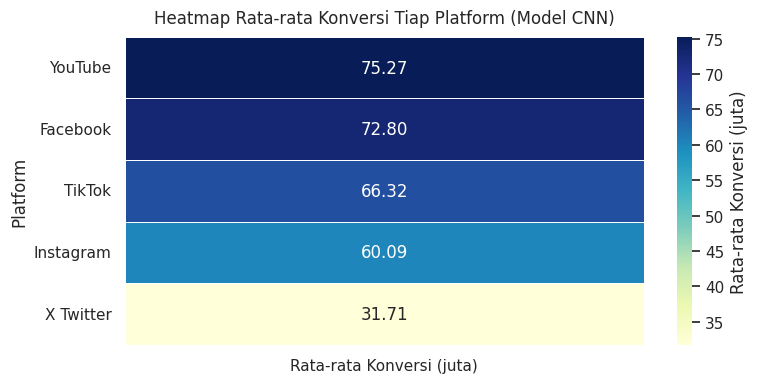

In [ ]:
# INTERPRETASI HASIL CNN + HEATMAP
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_pred = pd.read_excel('prediksi_platform_cnn.xlsx')
df_test = pd.read_excel('data_testing_setelah_RFE.xlsx')
df_full = pd.read_excel('data_setelah_RFE.xlsx')

# Cek kesesuaian jumlah baris
print("Jumlah baris prediksi:", len(df_pred))
print("Jumlah baris testing:", len(df_test))
print("Jumlah baris data penuh:", len(df_full))

# Ambil platform sesuai index data testing
X_full = df_full.drop(columns=['Platform', 'Tren Konten', 'Konversi (juta)'])
y_full = df_full['Konversi (juta)']

_, X_test_index, _, _ = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

platform_testing = df_full.loc[X_test_index.index, 'Platform'].reset_index(drop=True)
df_pred['Platform'] = platform_testing

# Hitung rata-rata konversi
platform_summary = (
    df_pred.groupby('Platform')['Konversi_Predicted (juta)']
    .mean()
    .reset_index()
    .rename(columns={'Konversi_Predicted (juta)': 'Rata-rata Konversi (juta)'})
    .sort_values(by='Rata-rata Konversi (juta)', ascending=False)
)

print("\n Rata-rata Prediksi Konversi Tiap Platform (CNN):")
print(platform_summary)

# Tentukan platform terbaik
best_platform = platform_summary.iloc[0]
print(f"\n Platform terbaik: {best_platform['Platform']} ({best_platform['Rata-rata Konversi (juta)']:.2f} juta)")

# Simpan hasil
platform_summary.to_excel('hasil_interpretasi_platform_cnn.xlsx', index=False)
print("\n✅ Hasil tersimpan di 'hasil_interpretasi_platform_cnn.xlsx'")

# VISUALISASI HEATMAP
plt.figure(figsize=(8, 4))
ax = sns.heatmap(
    platform_summary.set_index('Platform')[['Rata-rata Konversi (juta)']],
    annot=True, fmt=".2f", cmap="YlGnBu",
    linewidths=0.5, cbar_kws={'label': 'Rata-rata Konversi (juta)'}
)

plt.title("Heatmap Rata-rata Konversi Tiap Platform (Model CNN)", fontsize=12, pad=10)
plt.xlabel("")
plt.ylabel("Platform")
plt.tight_layout()
plt.savefig('heatmap_rata-rata_konversi_tiap_platform.png', dpi=600)
plt.show()
